# Momentum Crash Exploratory Analysis

Goldman High Beta Index down 24%, MS Tech Momentum 17-day ROC down 35%.
This notebook dissects the sell-off, identifies historical analogs, and builds candidate mean-reversion strategies.

## 0. Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from maroczy.datafeed import LSEData
from maroczy.features import bubble, covariance
from maroczy.features.macro import recession_probability, pca_curve_factors
from maroczy.characteristics import CharacteristicEngine
from maroczy.characteristics.functions import get_function
from maroczy.strategy import zscore, rank_signal, combine_signals, long_short_weights, run_backtest

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

lse = LSEData()

## 1. Pull universe & benchmark data

Large-cap US equities tilted towards high-beta / momentum names most likely caught in the unwind, plus broad benchmarks.

In [5]:
# High-beta / momentum-heavy names
momentum_names = ["NVDA", "META", "TSLA", "AMD", "AVGO", "MRVL", "PANW", "CRWD", "PLTR", "COIN"]
# Defensive / low-beta for comparison
defensive_names = ["JNJ", "PG", "KO", "PEP", "WMT", "UNH", "LLY", "MRK", "CL", "SO"]
# Broad benchmarks
benchmarks = ["SPY", "QQQ", "IWM"]

all_symbols = momentum_names + defensive_names + benchmarks

# force_refresh=True bypasses the local DuckDB cache (some symbols had stale
# cached bars stopping in 2023) and start= pins every symbol to the same
# window so the merged frame below actually has overlapping trading days.
history_start = "2021-06-01"  # COIN's IPO -- the binding constraint on lookback
bars = {s: lse.candles(s, timeframe="1d", start=history_start, force_refresh=True) for s in all_symbols}

empty_symbols = [s for s, b in bars.items() if b.empty]
if empty_symbols:
    print(f"No candles returned for: {empty_symbols}")
for s, b in bars.items():
    if not b.empty:
        print(f"{s:>6}: {len(b):4d} rows, {b.index[0].date()} to {b.index[-1].date()}")

all_symbols = [s for s in all_symbols if not bars[s].empty]
closes = pd.DataFrame({s: bars[s]["close"] for s in all_symbols}).dropna()
returns = closes.pct_change().dropna()

print(f"Universe: {len(all_symbols)} symbols, {len(returns)} trading days")
print(f"Date range: {returns.index[0].date()} to {returns.index[-1].date()}")
closes.tail(3)

  NVDA: 1293 rows, 2021-06-01 to 2026-07-15
  META: 1028 rows, 2022-06-09 to 2026-07-15
  TSLA: 1293 rows, 2021-06-01 to 2026-07-15
   AMD: 1289 rows, 2021-06-01 to 2026-07-15
  AVGO: 1289 rows, 2021-06-01 to 2026-07-15
  MRVL: 1290 rows, 2021-06-01 to 2026-07-15
  PANW: 1289 rows, 2021-06-01 to 2026-07-15
  CRWD: 1288 rows, 2021-06-01 to 2026-07-15
  PLTR: 1289 rows, 2021-06-01 to 2026-07-15
  COIN:   50 rows, 2026-04-27 to 2026-07-15
   JNJ: 1293 rows, 2021-06-01 to 2026-07-15
    PG: 1289 rows, 2021-06-01 to 2026-07-15
    KO: 1293 rows, 2021-06-01 to 2026-07-15
   PEP: 1293 rows, 2021-06-01 to 2026-07-15
   WMT: 1293 rows, 2021-06-01 to 2026-07-15
   UNH: 1289 rows, 2021-06-01 to 2026-07-15
   LLY: 1293 rows, 2021-06-01 to 2026-07-15
   MRK: 1293 rows, 2021-06-01 to 2026-07-15
    CL: 1377 rows, 2021-06-01 to 2026-07-15
    SO: 1293 rows, 2021-06-01 to 2026-07-15
   SPY:   59 rows, 2026-04-27 to 2026-07-16
   QQQ:   49 rows, 2026-04-27 to 2026-07-15
   IWM:   59 rows, 2026-04-27 to

,NVDA,META,TSLA,AMD,AVGO,MRVL,PANW,CRWD,PLTR,COIN,...,PEP,WMT,UNH,LLY,MRK,CL,SO,SPY,QQQ,IWM
ts,,,,,,,,,,,,,,,,,,,,,
2026-07-13 00:00:00+00:00,203.25,655.94,393.05,532.62,383.98,214.08,328.82,186.59,128.99,156.8,...,138.54,114.95,428.63,1180.48,123.74,93.74,96.47,748.20,710.65,292.94
2026-07-14 00:00:00+00:00,211.82,661.68,395.82,549.84,391.01,223.48,353.00,211.78,134.28,163.0,...,135.70,113.73,425.64,1154.90,121.10,91.45,95.62,753.10,722.09,294.89
2026-07-15 00:00:00+00:00,211.28,679.88,394.81,528.31,393.50,204.58,354.11,207.27,133.79,166.6,...,135.59,112.86,416.00,1157.99,123.41,91.50,95.49,754.68,717.40,295.82


## 2. Crash anatomy: characterize the drawdown

In [7]:
# Recent performance across multiple windows
windows = {"5d": 5, "17d": 17, "1m": 21, "3m": 63}

perf = pd.DataFrame({
    label: closes.pct_change(w).iloc[-1]
    for label, w in windows.items()
})

perf["bucket"] = (["momentum"] * len(momentum_names)
                  + ["defensive"] * len(defensive_names)
                  + ["benchmark"] * len(benchmarks))

window_cols = list(windows.keys())
perf.sort_values("17d").style.format("{:.1%}", subset=window_cols).background_gradient(
    cmap="RdYlGn", subset=window_cols, axis=0)

C:\Users\mawr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\io\formats\style.py:3807: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
C:\Users\mawr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\io\formats\style.py:3808: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,5d,17d,1m,3m,bucket
MRVL,-12.8%,-25.4%,-25.0%,nan%,momentum
WMT,-0.2%,-5.9%,-4.8%,nan%,defensive
PEP,-5.4%,-5.5%,-4.8%,nan%,defensive
TSLA,0.2%,-1.0%,0.9%,nan%,momentum
PG,-0.3%,-0.8%,1.0%,nan%,defensive
LLY,-5.1%,-0.0%,3.1%,nan%,defensive
KO,-1.1%,0.3%,4.0%,nan%,defensive
QQQ,0.7%,1.2%,2.4%,nan%,benchmark
CL,-1.6%,2.0%,3.2%,nan%,defensive
MRK,-2.1%,2.3%,2.3%,nan%,defensive


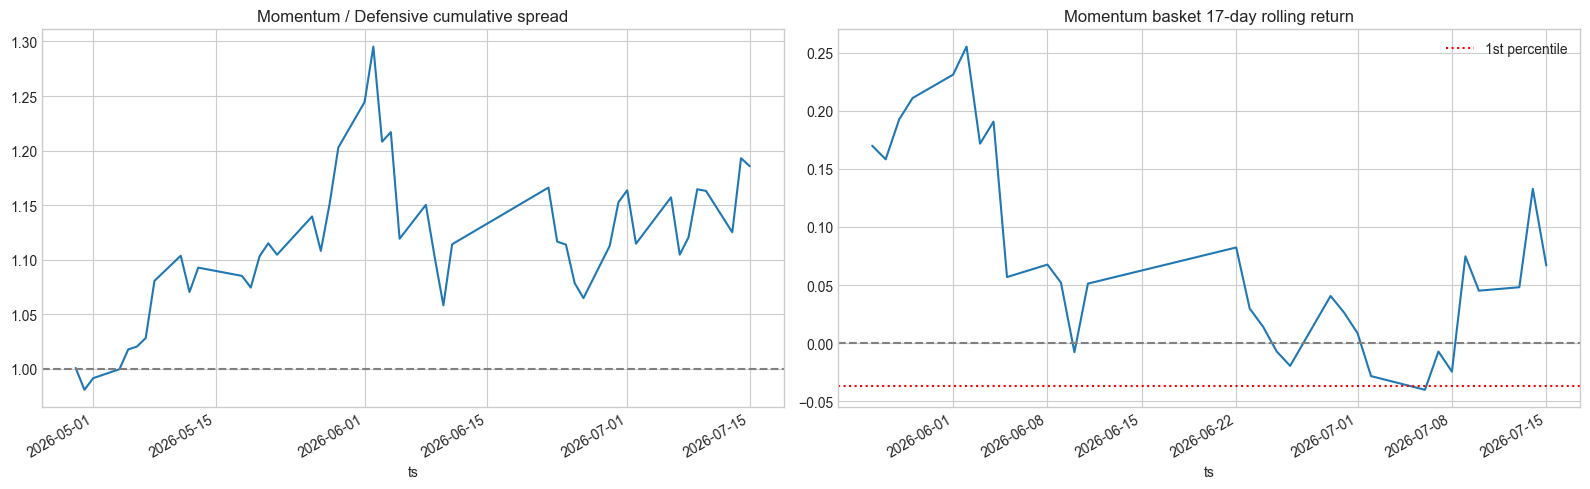

In [8]:
# Momentum vs defensive spread
mom_basket = returns[momentum_names].mean(axis=1)
def_basket = returns[defensive_names].mean(axis=1)
spread = (1 + mom_basket).cumprod() / (1 + def_basket).cumprod()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

spread.plot(ax=axes[0], title="Momentum / Defensive cumulative spread")
axes[0].axhline(1, color="gray", ls="--")

mom_17d = mom_basket.rolling(17).apply(lambda x: (1 + x).prod() - 1)
mom_17d.plot(ax=axes[1], title="Momentum basket 17-day rolling return")
axes[1].axhline(0, color="gray", ls="--")
axes[1].axhline(mom_17d.quantile(0.01), color="red", ls=":", label="1st percentile")
axes[1].legend()
plt.tight_layout()

In [9]:
# Is the current drawdown historically extreme?
trailing_17d = mom_basket.rolling(17).apply(lambda x: (1 + x).prod() - 1)
current = trailing_17d.iloc[-1]
percentile = (trailing_17d < current).mean()

print(f"Current 17d momentum basket return: {current:.1%}")
print(f"Historical percentile: {percentile:.1%} (worse than {1-percentile:.1%} of history)")
print()

crash_dates = trailing_17d[trailing_17d <= current].index
if len(crash_dates) > 0:
    print(f"Prior episodes with >= this magnitude ({len(crash_dates)} days):")
    gaps = pd.Series(crash_dates).diff().dt.days.fillna(100)
    episode_id = (gaps > 20).cumsum()
    for eid in episode_id.unique():
        ep_dates = crash_dates[episode_id.values == eid]
        print(f"  {ep_dates[0].date()} to {ep_dates[-1].date()} "
              f"({len(ep_dates)}d, trough: {trailing_17d.loc[ep_dates].min():.1%})")
else:
    print("No prior episode of this magnitude in sample.")

Current 17d momentum basket return: 6.7%
Historical percentile: 37.0% (worse than 63.0% of history)

Prior episodes with >= this magnitude (18 days):
  2026-06-05 to 2026-07-15 (18d, trough: -4.0%)


## 3. Factor decomposition: what is being sold?

In [10]:
engine = CharacteristicEngine()
mkt_ret = returns["SPY"]

char_names = ["ret_12_1", "ret_1_0", "retvol", "beta_60m",
              "ami_126d", "bidaskhl_21d", "ivol_capm_21d"]
chars = engine.compute_universe(
    {s: bars[s] for s in momentum_names + defensive_names},
    names=char_names, mkt_ret=mkt_ret,
)

latest = chars.xs(chars.index.get_level_values(0)[-1], level=0)
latest["bucket"] = ["momentum" if s in momentum_names else "defensive"
                     for s in latest.index.get_level_values("symbol")]
latest.groupby("bucket")[char_names].mean().T.style.format("{:.3f}").background_gradient(cmap="RdYlGn", axis=1)

C:\Users\mawr\AppData\Local\Temp\ipykernel_13812\4120612993.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  latest["bucket"] = ["momentum" if s in momentum_names else "defensive"
C:\Users\mawr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\io\formats\style.py:3807: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
C:\Users\mawr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\io\formats\style.py:3808: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


bucket,defensive,momentum
ret_12_1,0.219,0.737
ret_1_0,0.006,0.065
retvol,0.016,0.040
beta_60m,nan,nan
ami_126d,0.003,0.007
bidaskhl_21d,0.007,0.014
ivol_capm_21d,0.015,0.032


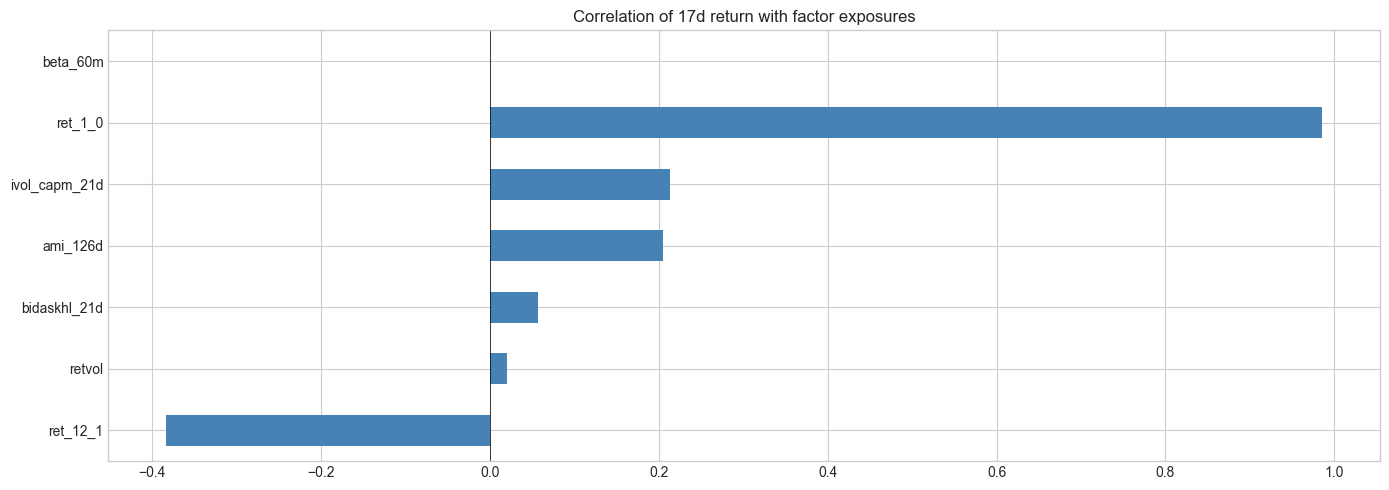

In [11]:
# What factor exposures predict the crash return?
recent_ret = closes[momentum_names + defensive_names].pct_change(17).iloc[-1]
factor_corr = latest.drop(columns="bucket").corrwith(recent_ret)

factor_corr.sort_values().plot.barh(
    title="Correlation of 17d return with factor exposures", color="steelblue")
plt.axvline(0, color="black", lw=0.5)
plt.tight_layout()

## 4. Macro context: rates / vol regime shift?

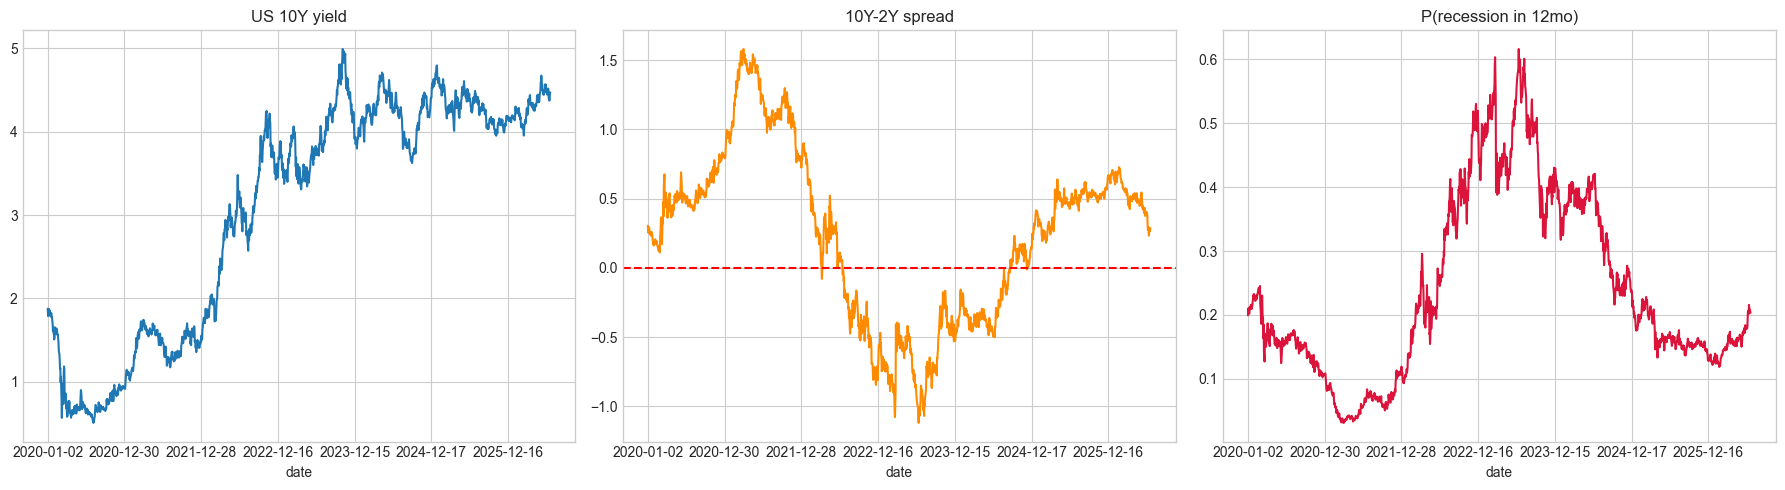

In [12]:
us10y = lse.bond_yields("US10Y", start="2020-01-01")
us2y = lse.bond_yields("US2Y", start="2020-01-01")

yields = pd.DataFrame({
    "US10Y": us10y.set_index("date")["close"],
    "US2Y": us2y.set_index("date")["close"]
}).dropna()
yields["slope"] = yields["US10Y"] - yields["US2Y"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
yields["US10Y"].plot(ax=axes[0], title="US 10Y yield")
yields["slope"].plot(ax=axes[1], title="10Y-2Y spread", color="darkorange")
axes[1].axhline(0, color="red", ls="--")

rec_prob = recession_probability(yields["slope"])
rec_prob.plot(ax=axes[2], title="P(recession in 12mo)", color="crimson")
plt.tight_layout()

Current 21d RV: 11.0%
Percentile: 0%


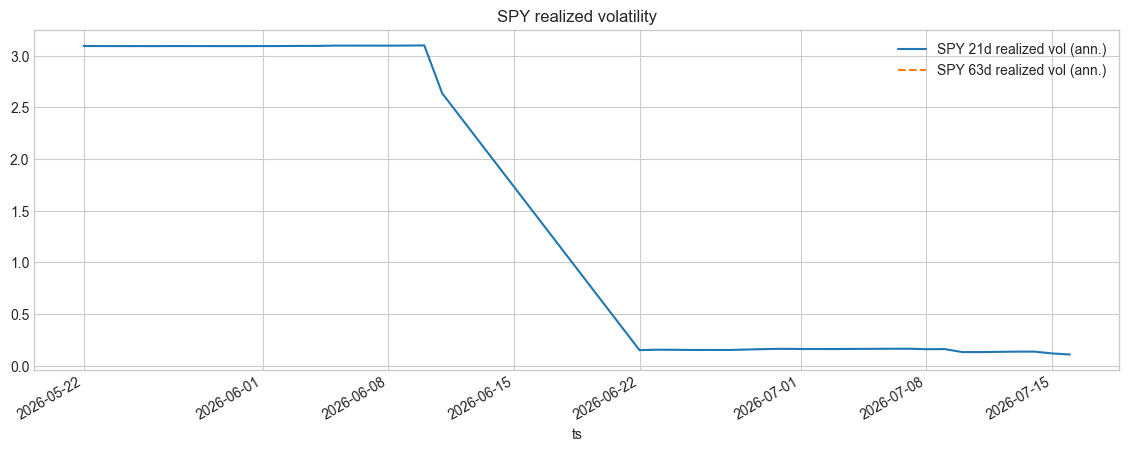

In [13]:
# Realized vol context
spy_ret = bars["SPY"]["close"].pct_change()
rv_21 = spy_ret.rolling(21).std() * np.sqrt(252)
rv_63 = spy_ret.rolling(63).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(14, 5))
rv_21.plot(ax=ax, label="SPY 21d realized vol (ann.)")
rv_63.plot(ax=ax, label="SPY 63d realized vol (ann.)", ls="--")
ax.set_title("SPY realized volatility")
ax.legend()

print(f"Current 21d RV: {rv_21.iloc[-1]:.1%}")
print(f"Percentile: {(rv_21 < rv_21.iloc[-1]).mean():.0%}")

## 5. Historical analog: forward returns after prior momentum crashes

In [14]:
threshold = trailing_17d.quantile(0.02)
crash_mask = trailing_17d <= threshold
crash_starts = crash_mask & ~crash_mask.shift(1, fill_value=False)
episode_dates = trailing_17d.index[crash_starts]

forward_windows = [5, 10, 21, 42, 63]
analog_table = []
for date in episode_dates:
    loc = trailing_17d.index.get_loc(date)
    row = {"crash_date": date.date(), "crash_17d_ret": trailing_17d.iloc[loc]}
    for fw in forward_windows:
        if loc + fw < len(mom_basket):
            row[f"fwd_{fw}d"] = (1 + mom_basket.iloc[loc:loc+fw]).prod() - 1
    analog_table.append(row)

analogs = pd.DataFrame(analog_table).set_index("crash_date")
print(f"{len(analogs)} prior crash episodes (bottom 2% of 17d momentum returns)")
analogs.style.format("{:.1%}").background_gradient(cmap="RdYlGn", axis=0)

1 prior crash episodes (bottom 2% of 17d momentum returns)


,crash_17d_ret,fwd_5d
crash_date,,
2026-07-06,-4.0%,2.4%


In [15]:
# Average forward path after momentum crash
forward_days = 63
paths = []
for date in episode_dates:
    loc = trailing_17d.index.get_loc(date)
    if loc + forward_days < len(mom_basket):
        path = (1 + mom_basket.iloc[loc:loc+forward_days]).cumprod()
        path = path / path.iloc[0]
        path.index = range(len(path))
        paths.append(path)

if paths:
    path_df = pd.DataFrame(paths).T
    fig, ax = plt.subplots(figsize=(12, 5))
    path_df.plot(ax=ax, alpha=0.3, legend=False, color="steelblue")
    path_df.mean(axis=1).plot(ax=ax, color="black", lw=2, label="Average path")
    path_df.median(axis=1).plot(ax=ax, color="red", lw=2, ls="--", label="Median path")
    ax.set_xlabel("Trading days after crash")
    ax.set_ylabel("Cumulative return (indexed to 1)")
    ax.set_title(f"Forward path after {len(paths)} prior crash episodes")
    ax.axhline(1, color="gray", ls=":")
    ax.legend()
else:
    print("Not enough history for forward paths.")

Not enough history for forward paths.


## 6. Bubble detection on the momentum spread

GSADF stat: 1.53
95% CV: 2.00
Explosive bubble detected: False


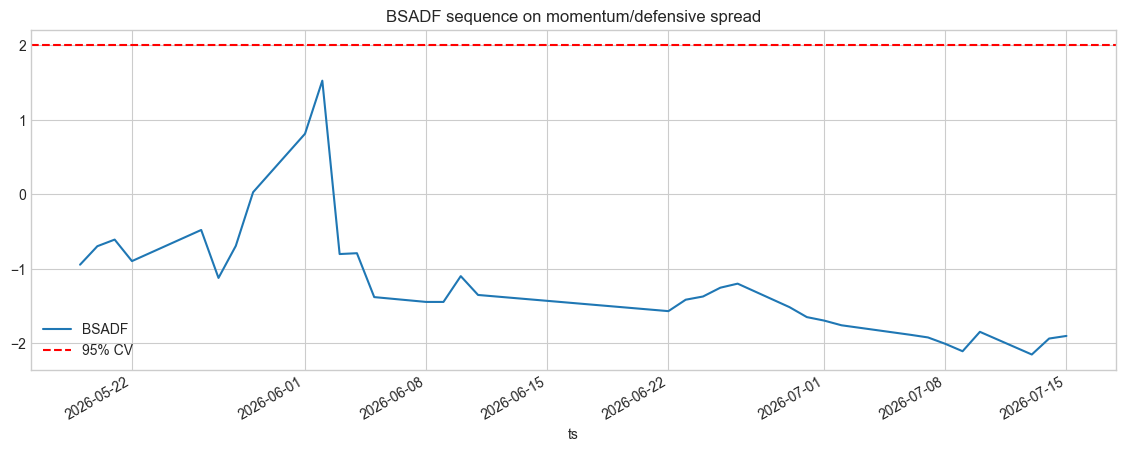

In [16]:
spread_level = (1 + mom_basket).cumprod() / (1 + def_basket).cumprod()

result = bubble.gsadf(spread_level.dropna())
cv = bubble.critical_values(len(spread_level.dropna()))

print(f"GSADF stat: {result.stat:.2f}")
print(f"95% CV: {cv['gsadf'][0.95]:.2f}")
print(f"Explosive bubble detected: {result.stat > cv['gsadf'][0.95]}")

fig, ax = plt.subplots(figsize=(14, 5))
result.bsadf.plot(ax=ax, label="BSADF")
ax.axhline(cv["gsadf"][0.95], color="red", ls="--", label="95% CV")
ax.set_title("BSADF sequence on momentum/defensive spread")
ax.legend()

## 7. Strategy candidates

### 7a. Crash mean-reversion: buy the most oversold momentum names

In [17]:
stock_universe = momentum_names + defensive_names
stock_returns = returns[stock_universe]
stock_closes = closes[stock_universe]

# Signal: z-scored 17-day return (most negative = buy candidate)
ret_17d = stock_closes.pct_change(17)
signal_reversal = -zscore(ret_17d, axis=1)

# Only trade when crash regime is active (17d basket return < -10%)
regime_on = mom_basket.rolling(17).apply(lambda x: (1 + x).prod() - 1) < -0.10
signal_cond = signal_reversal.where(regime_on, 0)

weights_rev = signal_cond.apply(
    lambda row: long_short_weights(row, n_long=5, n_short=0)
    if row.abs().sum() > 0 else row * 0, axis=1)

result_rev = run_backtest(weights_rev, stock_returns, cost_bps=10.0)
print("Crash mean-reversion (conditional on crash regime):")
print(result_rev)

Crash mean-reversion (conditional on crash regime):
BacktestResult(sharpe=nan, ann_return=0.00%, ann_vol=0.00%, max_drawdown=0.00%, avg_turnover=0.00%)


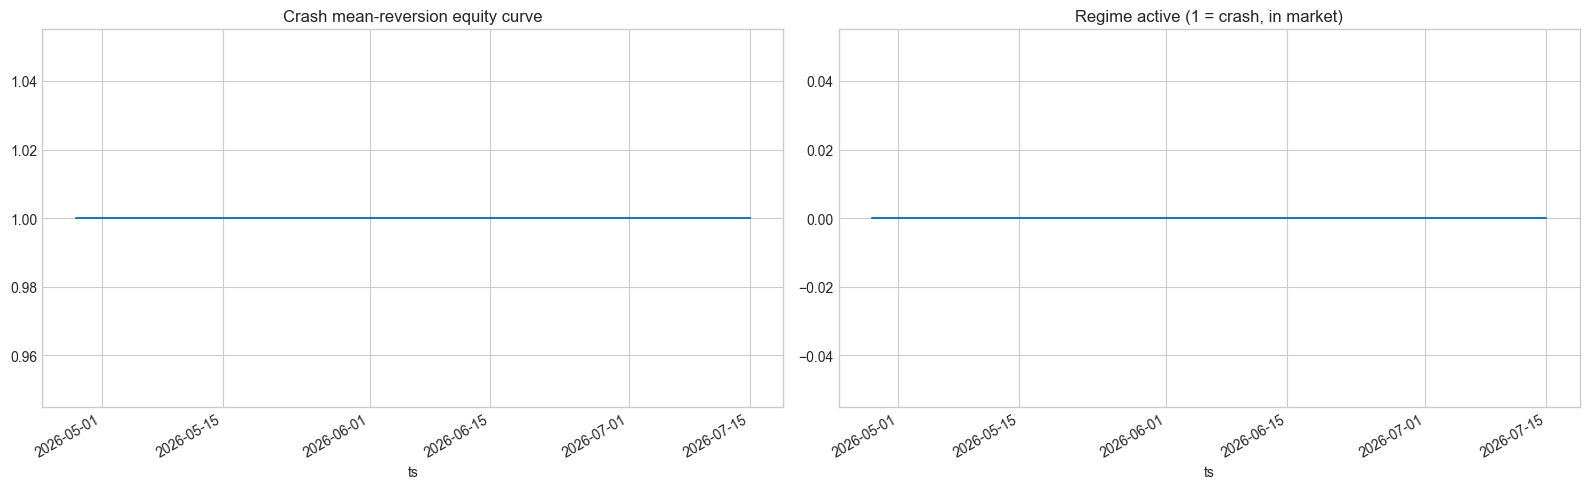

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
result_rev.equity_curve.plot(ax=axes[0], title="Crash mean-reversion equity curve")
active = (weights_rev.abs().sum(axis=1) > 0).astype(float)
active.plot(ax=axes[1], title="Regime active (1 = crash, in market)")
plt.tight_layout()

### 7b. Composite: reversal + low-vol quality filter

In [19]:
rvol = stock_returns.rolling(21).std() * np.sqrt(252)
signal_lowvol = -zscore(rvol, axis=1)

composite = 0.6 * zscore(signal_reversal, axis=1) + 0.4 * zscore(signal_lowvol, axis=1)
composite_cond = composite.where(regime_on, 0)

weights_comp = composite_cond.apply(
    lambda row: long_short_weights(row, n_long=5, n_short=0)
    if row.abs().sum() > 0 else row * 0, axis=1)

result_comp = run_backtest(weights_comp, stock_returns, cost_bps=10.0)
print("Composite (reversal + low-vol quality filter):")
print(result_comp)

Composite (reversal + low-vol quality filter):
BacktestResult(sharpe=nan, ann_return=0.00%, ann_vol=0.00%, max_drawdown=0.00%, avg_turnover=0.00%)


### 7c. Long/short crash reversal

In [20]:
weights_ls = signal_cond.apply(
    lambda row: long_short_weights(row, n_long=5, n_short=5)
    if row.abs().sum() > 0 else row * 0, axis=1)

result_ls = run_backtest(weights_ls, stock_returns, cost_bps=10.0)
print("Long/short crash reversal:")
print(result_ls)

Long/short crash reversal:
BacktestResult(sharpe=nan, ann_return=0.00%, ann_vol=0.00%, max_drawdown=0.00%, avg_turnover=0.00%)


,ann_return,ann_vol,sharpe,max_drawdown,avg_turnover,hit_rate
Mean-Rev,0.0,0.0,NaN,0.0,0.0,0.0
Composite,0.0,0.0,NaN,0.0,0.0,0.0
L/S,0.0,0.0,NaN,0.0,0.0,0.0


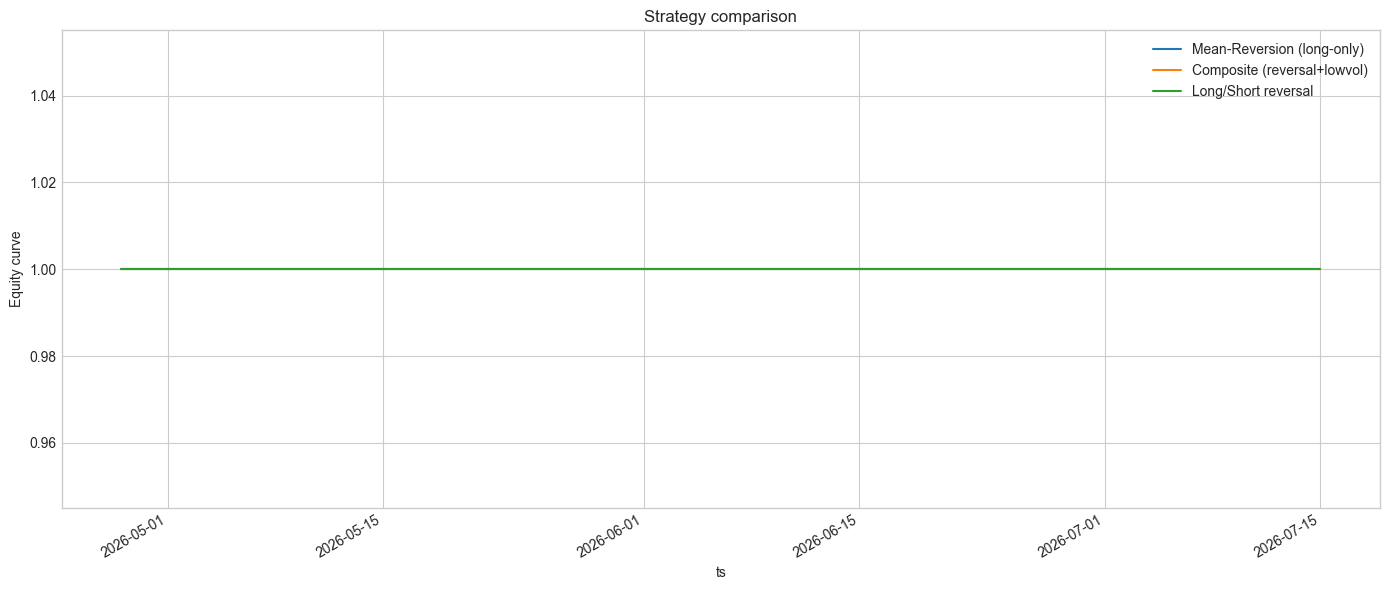

In [21]:
# Compare all three
comparison = pd.DataFrame({
    "Mean-Reversion (long-only)": result_rev.equity_curve,
    "Composite (reversal+lowvol)": result_comp.equity_curve,
    "Long/Short reversal": result_ls.equity_curve,
})
comparison.plot(figsize=(14, 6), title="Strategy comparison")
plt.ylabel("Equity curve")
plt.tight_layout()

pd.DataFrame({
    "Mean-Rev": result_rev.stats,
    "Composite": result_comp.stats,
    "L/S": result_ls.stats,
}).T

## 8. Options overlay: is the market pricing recovery or further downside?

In [ ]:
chain = lse.options_chain("NVDA", max_dte=120)

if chain is not None and not chain.empty:
    spot = bars["NVDA"]["close"].iloc[-1]
    rv = (stock_returns["NVDA"].rolling(21).std().iloc[-1] * np.sqrt(252)
          if "NVDA" in stock_returns.columns else 0.3)

    print(f"NVDA spot: ${spot:.2f}")
    print(f"ATM IV:         {get_function('iv_atm')(chain, spot):.1%}")
    print(f"25d skew:       {get_function('iv_skew_25d')(chain, spot):.1%}")
    print(f"Term slope:     {get_function('iv_term_slope')(chain, spot):.1%}")
    print(f"Put/call ratio: {get_function('put_call_ratio')(chain):.2f}")
    print(f"VRP (IV-RV):    {get_function('variance_risk_premium')(chain, spot, rv):.4f}")
    print(f"Max pain:       ${get_function('max_pain')(chain):.0f}")
else:
    print("Options chain not available.")

## 9. Correlation structure: forced liquidation signature?

In [ ]:
mom_rets = returns[momentum_names]
rolling_corr = mom_rets.rolling(21).corr()

avg_corr = rolling_corr.groupby(level=0).apply(
    lambda x: x.values[np.triu_indices(len(momentum_names), k=1)].mean())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

avg_corr.plot(ax=axes[0], title="Avg pairwise correlation (momentum names)")
axes[0].axhline(avg_corr.mean(), color="gray", ls="--", label="long-run mean")
axes[0].legend()

recent_rets = mom_rets.iloc[-63:]
raw_corr = recent_rets.corr()
cleaned = covariance.clean_covariance(recent_rets, method="cv")

eig_raw = np.linalg.eigvalsh(raw_corr)
eig_clean = np.linalg.eigvalsh(cleaned)

axes[1].bar(range(len(eig_raw)), sorted(eig_raw, reverse=True), alpha=0.5, label="Raw")
axes[1].bar(range(len(eig_clean)), sorted(eig_clean, reverse=True), alpha=0.5, label="Cleaned")
axes[1].set_title("Eigenvalue spectrum (last 63d)")
axes[1].legend()

pct1 = sorted(eig_raw, reverse=True)[0] / sum(eig_raw)
print(f"PC1 explains {pct1:.0%} of variance "
      f"{'-- HIGH (crowded unwind)' if pct1 > 0.6 else '-- normal'}")
plt.tight_layout()

## 10. Current positioning: which names to watch

In [ ]:
scoring = pd.DataFrame(index=momentum_names)
scoring["17d_return"] = closes[momentum_names].pct_change(17).iloc[-1]
scoring["dd_from_high"] = closes[momentum_names].iloc[-1] / closes[momentum_names].rolling(252).max().iloc[-1] - 1
scoring["21d_rvol"] = (stock_returns[momentum_names].rolling(21).std() * np.sqrt(252)).iloc[-1]
scoring["ret_12_1"] = closes[momentum_names].pct_change(252).iloc[-1]

scoring["reversal_z"] = zscore(-scoring["17d_return"])
scoring["vol_z"] = zscore(-scoring["21d_rvol"])
scoring["mom_z"] = zscore(scoring["ret_12_1"])
scoring["composite"] = 0.5 * scoring["reversal_z"] + 0.25 * scoring["vol_z"] + 0.25 * scoring["mom_z"]

scoring.sort_values("composite", ascending=False).style.format("{:.2f}").background_gradient(
    cmap="RdYlGn", subset=["composite", "17d_return", "dd_from_high"])

## 11. Key takeaways

Fill in after running:

- **Crash severity**: ?
- **Historical analog behavior**: ?
- **Bubble prior to crash?**: ?
- **Macro trigger**: ?
- **Correlation spike (forced liquidation)?**: ?
- **Best strategy candidate**: ?
- **Top names for entry**: ?